<a href="https://colab.research.google.com/github/jbui106/107-final/blob/main/Iris_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
K-Nearest Neighbors (KNN) Classification
Dataset : Iris (from scikit-learn)
Key features :
    • StandardScaler feature scaling
    • Minkowski distance (p = 3); if p=1, Manhattan distance, if p=2, Euclidean distance
    • 10-fold cross-validation for a range of odd k values
    • CV-accuracy plot
    • Final test-set accuracy report
"""

# -----------------------------
# 1. Imports
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score



In [ ]:
# -----------------------------
# 2. Load data into a DataFrame
# -----------------------------
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

X = df.drop(columns='target')
y = df['target']


print(X.head)
print(y.head)

<bound method NDFrame.head of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]>
<bound me

In [ ]:
# -----------------------------
# 3. Train-test split (80/20)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=35, stratify=y
)

print(len(X_train))
print(len(X_test))

120
30


In [ ]:
# -----------------------------
# 4. Feature scaling
# -----------------------------

# Use the mean and standard deviation already learned from the training data to scale the test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(X_train_scaled)
print(X)

[[-1.76648818e+00 -1.52106324e-01 -1.39023616e+00 -1.32341377e+00]
 [ 1.10779767e+00 -1.52106324e-01  9.57883898e-01  1.18897873e+00]
 [-5.68869075e-01  1.57450600e+00 -1.27842092e+00 -1.32341377e+00]
 [ 5.08988119e-01  5.87870386e-01  5.10622934e-01  5.27822810e-01]
 [ 9.88035761e-01  9.45525795e-02  1.01379152e+00  1.58567228e+00]
 [-5.68869075e-01  2.06782380e+00 -1.39023616e+00 -1.05895140e+00]
 [-1.04791672e+00  1.32784710e+00 -1.33432854e+00 -1.32341377e+00]
 [ 5.08988119e-01 -1.38540084e+00  6.22438175e-01  3.95591626e-01]
 [ 5.08988119e-01 -3.98765227e-01  1.01379152e+00  7.92285179e-01]
 [-5.68869075e-01  8.34529289e-01 -1.16660568e+00 -1.32341377e+00]
 [ 9.88035761e-01 -1.52106324e-01  6.78345796e-01  6.60053994e-01]
 [ 7.48511940e-01 -6.45424130e-01  4.54715314e-01  3.95591626e-01]
 [-1.40720245e+00  3.41211483e-01 -1.39023616e+00 -1.32341377e+00]
 [ 9.88035761e-01 -1.52106324e-01  7.90161037e-01  1.45344110e+00]
 [ 6.28750030e-01  3.41211483e-01  8.46068657e-01  1.45344110e

In [ ]:

# -----------------------------
# 5. Cross-validation to pick k
# -----------------------------

# Step 1: Define a list of odd k values to try
max_k = len(X_train_scaled) // 2
k_list = list(range(3, max_k, 2))

# Step 2: Prepare to store cross-validation results
cross_validation_scores = []
all_scores = {}

# Step 3: Create a KFold object
kf = KFold(n_splits=10, shuffle=True, random_state=35)

# Step 4: Run cross-validation for each k
for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=3)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=kf, scoring='accuracy')
    cross_validation_scores.append(scores.mean())
    all_scores[k] = scores

print(k_list)
print(cross_validation_scores)

[3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59]
[np.float64(0.9499999999999998), np.float64(0.9666666666666666), np.float64(0.9583333333333334), np.float64(0.975), np.float64(0.975), np.float64(0.975), np.float64(0.9833333333333332), np.float64(0.9416666666666667), np.float64(0.95), np.float64(0.9416666666666667), np.float64(0.925), np.float64(0.9166666666666667), np.float64(0.9), np.float64(0.9), np.float64(0.8916666666666666), np.float64(0.8833333333333332), np.float64(0.8833333333333332), np.float64(0.875), np.float64(0.8666666666666666), np.float64(0.8666666666666666), np.float64(0.875), np.float64(0.8666666666666666), np.float64(0.8666666666666666), np.float64(0.8666666666666666), np.float64(0.8666666666666666), np.float64(0.8583333333333332), np.float64(0.8583333333333332), np.float64(0.8583333333333332), np.float64(0.8666666666666666)]


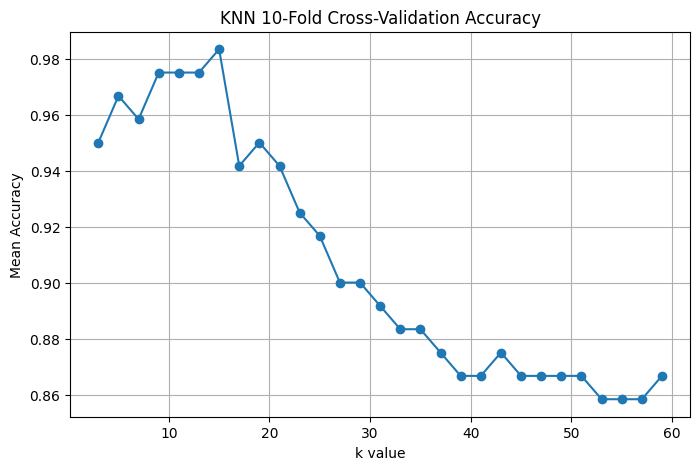

In [ ]:

# -----------------------------
# Step 6: Plot CV accuracy vs. k
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))
plt.plot(k_list, cross_validation_scores, marker='o')
plt.xlabel('k value')
plt.ylabel('Mean Accuracy')
plt.title('KNN 10-Fold Cross-Validation Accuracy')
plt.grid(True)
plt.show()



In [ ]:
# -----------------------------
# Step 7: Select the best k and retrain the model
# -----------------------------
best_k_index = np.argmax(cross_validation_scores)
best_k = k_list[best_k_index]
print(f"Best k from CV: {best_k}")

# Retrain the model using the best k
final_knn = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', p=3)
final_knn.fit(X_train_scaled, y_train)



Best k from CV: 15


KNeighborsClassifier(n_neighbors=15, p=3)

In [ ]:

# -----------------------------
# 8. Evaluate on test set
# -----------------------------
y_pred = final_knn.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test-set Accuracy: {test_acc:.3f}")

Test-set Accuracy: 0.900
